In [3]:
import sys
print("Python Executable:", sys.executable)

import tensorflow as tf
print("TensorFlow Version:", tf.__version__)

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

print("MNIST imported successfully!")

Python Executable: c:\Users\s raju\Desktop\MNIST_HandWritten Digit Classification CNN Model\env\Scripts\python.exe
TensorFlow Version: 2.21.0
MNIST imported successfully!


In [1]:
import tensorflow as tf
import cv2
import mediapipe as mp
import sklearn
import numpy as np

print(tf.__version__)
print(cv2.__version__)
print(mp.__version__)
print("Everything works!")

2.21.0
5.0.0
0.10.35
Everything works!


In [1]:
import sys
print(sys.executable)

c:\Users\s raju\Desktop\MNIST_HandWritten Digit Classification CNN Model\env\Scripts\python.exe


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cv2

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [1]:
!pip install -q mediapipe opencv-python keras-tuner

In [24]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [25]:
print("Training Images :", X_train.shape)

Training Images : (60000, 28, 28)


In [26]:
print("Training Labels :", y_train.shape)

Training Labels : (60000,)


In [27]:
print("Testing Images :", X_test.shape)

Testing Images : (10000, 28, 28)


In [28]:
print("Testing Labels :", y_test.shape)

Testing Labels : (10000,)


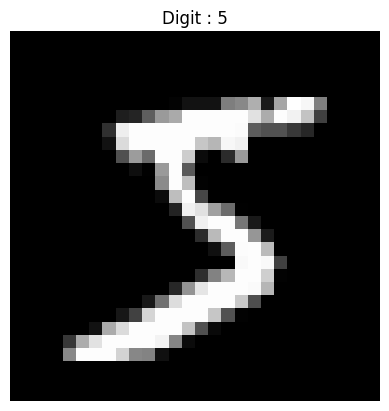

In [29]:
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Digit : {y_train[0]}")
plt.axis('off')
plt.show()

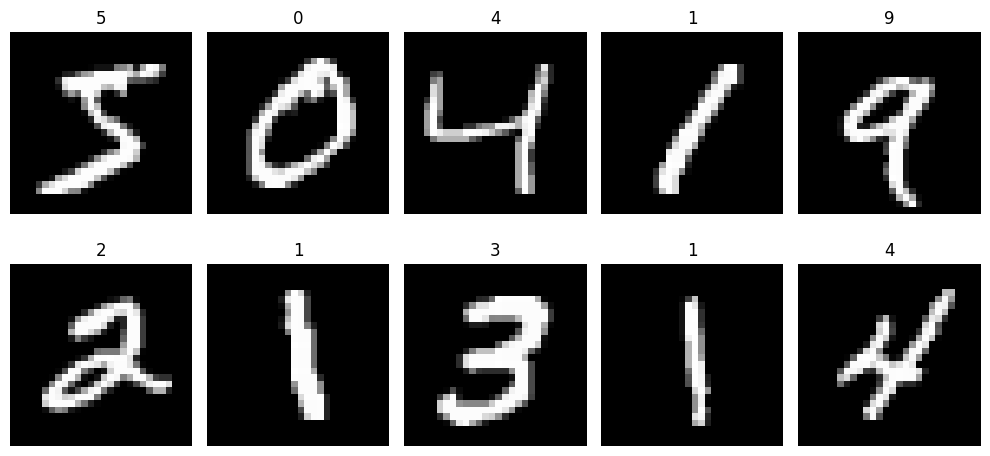

In [30]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [31]:
digit_count = pd.Series(y_train).value_counts().sort_index()

print(digit_count)

0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64


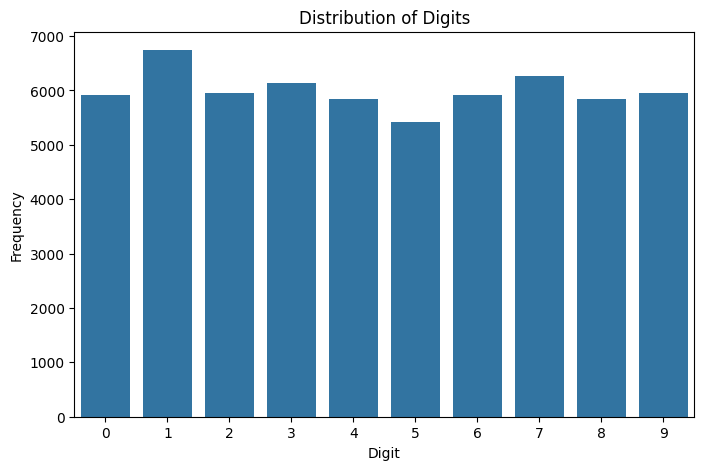

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=digit_count.index,
    y=digit_count.values
)

plt.xlabel("Digit")
plt.ylabel("Frequency")
plt.title("Distribution of Digits")
plt.show()

In [33]:
print("Minimum Pixel Value :", X_train.min())
print("Maximum Pixel Value :", X_train.max())

Minimum Pixel Value : 0
Maximum Pixel Value : 255


In [34]:
print("Image Height :", X_train.shape[1])
print("Image Width :", X_train.shape[2])

Image Height : 28
Image Width : 28


In [35]:
print(X_train.dtype)

uint8


In [36]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [37]:
print(X_train.min())
print(X_train.max())

0.0
1.0


In [38]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [39]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [40]:
X = X_train

In [41]:
y = y_train

In [42]:
print(X.shape)
print(y.shape)

(60000, 28, 28, 1)
(60000,)


In [43]:
y = to_categorical(y, num_classes=10)

In [44]:
print(y.shape)

(60000, 10)


In [45]:
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y, axis=1)
)

In [46]:
print("Training Images :", X_train_final.shape)
print("Validation Images :", X_val.shape)
print("Testing Images :", X_test.shape)

print()

print("Training Labels :", y_train_final.shape)
print("Validation Labels :", y_val.shape)
print("Testing Labels :", y_test.shape)

Training Images : (48000, 28, 28, 1)
Validation Images : (12000, 28, 28, 1)
Testing Images : (10000, 28, 28, 1)

Training Labels : (48000, 10)
Validation Labels : (12000, 10)
Testing Labels : (10000,)


In [47]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [48]:
y_test_cat = to_categorical(y_test, num_classes=10)

In [49]:
baseline_model = Sequential([

    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

In [50]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [51]:
baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [52]:
history_baseline = baseline_model.fit(

    X_train_final,
    y_train_final,

    validation_data=(X_val, y_val),

    epochs=10,

    batch_size=32,

    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.9514 - loss: 0.1624 - val_accuracy: 0.9728 - val_loss: 0.0867
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.9830 - loss: 0.0546 - val_accuracy: 0.9822 - val_loss: 0.0640
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.9895 - loss: 0.0340 - val_accuracy: 0.9847 - val_loss: 0.0537
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 24ms/step - accuracy: 0.9928 - loss: 0.0229 - val_accuracy: 0.9857 - val_loss: 0.0552
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.9952 - loss: 0.0149 - val_accuracy: 0.9858 - val_loss: 0.0544
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 37s 25ms/step - accuracy: 0.9968 - loss: 0.0104 - val_accuracy: 0.9847 - val_loss: 0.0590
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 24ms/step - accuracy: 0.9974 - loss: 0.0082 - val_accuracy: 0.9868 - val_loss: 0.0611
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 24ms/step - accuracy: 0.9979 -

In [53]:
loss, accuracy = baseline_model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print("Baseline Test Accuracy :", accuracy)
print("Baseline Test Loss :", loss)

Baseline Test Accuracy : 0.9851999878883362
Baseline Test Loss : 0.05984855815768242


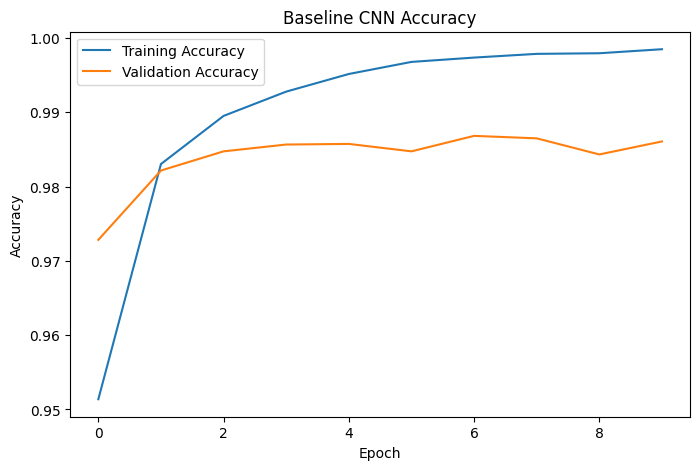

In [54]:
plt.figure(figsize=(8,5))

plt.plot(history_baseline.history['accuracy'], label='Training Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN Accuracy")
plt.legend()

plt.show()

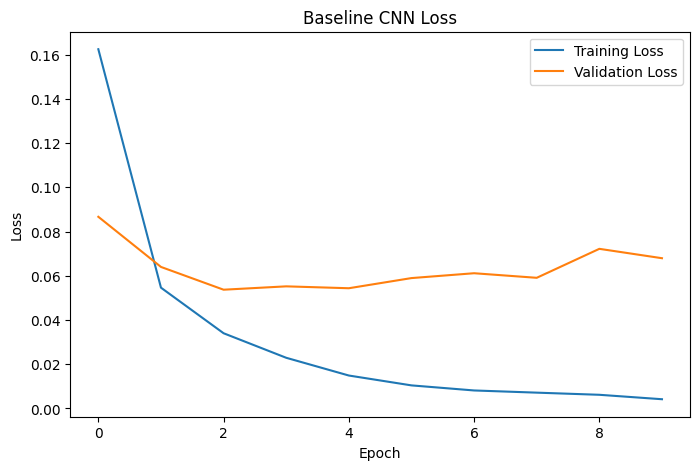

In [55]:
plt.figure(figsize=(8,5))

plt.plot(history_baseline.history['loss'], label='Training Loss')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN Loss")
plt.legend()

plt.show()

In [56]:
pip install keras-tuner

In [57]:
import keras_tuner as kt

In [58]:
def build_model(hp):

    model = Sequential()

    model.add(
        Conv2D(

            filters=hp.Choice(
                'filters',
                values=[32,64]
            ),

            kernel_size=(3,3),

            activation='relu',

            input_shape=(28,28,1)
        )
    )

    model.add(BatchNormalization())

    model.add(MaxPooling2D())

    model.add(Dropout(

        hp.Float(
            'dropout1',
            min_value=0.2,
            max_value=0.5,
            step=0.1
        )

    ))

    model.add(

        Conv2D(

            filters=hp.Choice(
                'filters2',
                values=[64,128]
            ),

            kernel_size=(3,3),

            activation='relu'

        )

    )

    model.add(BatchNormalization())

    model.add(MaxPooling2D())

    model.add(Flatten())

    model.add(

        Dense(

            units=hp.Choice(
                'dense_units',
                values=[128,256]
            ),

            activation='relu'

        )

    )

    model.add(

        Dropout(

            hp.Float(
                'dropout2',
                0.3,
                0.6,
                step=0.1
            )

        )

    )

    model.add(Dense(10, activation='softmax'))

    learning_rate = hp.Choice(
        'learning_rate',
        values=[1e-3,1e-4]
    )

    model.compile(

        optimizer=Adam(
            learning_rate=learning_rate
        ),

        loss='categorical_crossentropy',

        metrics=['accuracy']

    )

    return model

In [59]:
tuner = kt.RandomSearch(

    build_model,

    objective='val_accuracy',

    max_trials=5,

    overwrite=True,

    directory='cnn_tuning',

    project_name='digit_recognition'

)

In [60]:
tuner.search(

    X_train_final,

    y_train_final,

    validation_data=(X_val,y_val),

    epochs=5,

    batch_size=64

)

Trial 5 Complete [00h 14m 16s]
val_accuracy: 0.9884999990463257

Best val_accuracy So Far: 0.9895833134651184
Total elapsed time: 00h 51m 51s


In [62]:
best_hp = tuner.get_best_hyperparameters()[0]

print(best_hp.values)

{'filters': 32, 'dropout1': 0.30000000000000004, 'filters2': 64, 'dense_units': 128, 'dropout2': 0.4, 'learning_rate': 0.001}


In [63]:
best_model = tuner.hypermodel.build(best_hp)

In [64]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True

)

In [68]:
history = best_model.fit(

    X_train_final,

    y_train_final,

    validation_data=(X_val,y_val),

    epochs=20,

    batch_size=64,

    callbacks=[early_stop],

    verbose=1

)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 85s 113ms/step - accuracy: 0.9870 - loss: 0.0416 - val_accuracy: 0.9880 - val_loss: 0.0535
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 69s 92ms/step - accuracy: 0.9890 - loss: 0.0361 - val_accuracy: 0.9894 - val_loss: 0.0522
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 70s 93ms/step - accuracy: 0.9899 - loss: 0.0322 - val_accuracy: 0.9893 - val_loss: 0.0538
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 69s 91ms/step - accuracy: 0.9916 - loss: 0.0283 - val_accuracy: 0.9899 - val_loss: 0.0514
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 91ms/step - accuracy: 0.9913 - loss: 0.0293 - val_accuracy: 0.9879 - val_loss: 0.0598


In [69]:
loss, accuracy = best_model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print("Best CNN Accuracy :", accuracy)
print("Best CNN Loss :", loss)

Best CNN Accuracy : 0.9904999732971191
Best CNN Loss : 0.03397319093346596


In [70]:
predictions = best_model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


In [71]:
print(

    classification_report(

        y_test,

        predicted_labels

    )

)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      0.99      1.00      1135
           2       1.00      0.98      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.98      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.98      0.99      0.99       974
           9       0.98      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [72]:
cm = confusion_matrix(

    y_test,

    predicted_labels

)

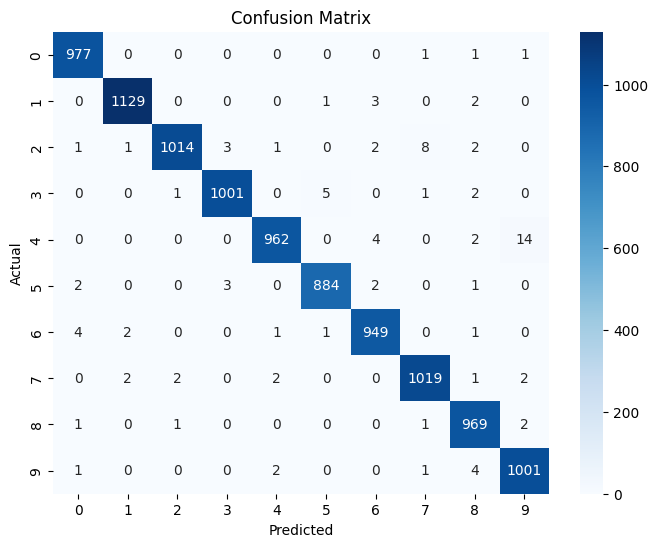

In [73]:
plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

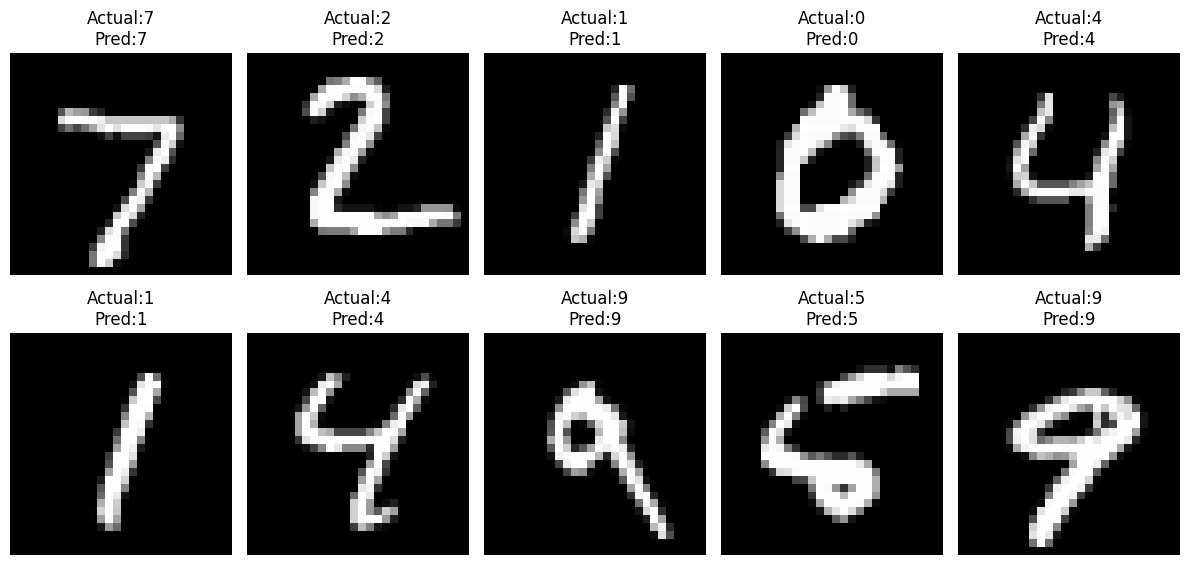

In [74]:
plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(
        X_test[i].reshape(28,28),
        cmap='gray'
    )

    plt.title(

        f"Actual:{y_test[i]}\nPred:{predicted_labels[i]}"

    )

    plt.axis('off')

plt.tight_layout()

plt.show()

In [75]:
import os

os.makedirs("models", exist_ok=True)

In [76]:
best_model.save("models/digit_cnn.keras")

In [77]:
print("Model saved successfully.")

Model saved successfully.
